# CrocoLake Temperature Map - North West Atlantic

This notebook shows how to read and visualize CrocoLake data stored in parquet format, creating a map of temperature measurements in the North West Atlantic.

CrocoLake contains QCed data from different datasets (Argo, GLODAP, Spray Gliders). We use the `ArgoData.jl` package (Forget, G., & collaborators) to read the parquet files.

- Milanese, E., & Nicholson, D. (2025). Sample parquet datasets of Argo program ocean data [Data set]. Zenodo. https://doi.org/10.5281/zenodo.15198578
- https://github.com/boom-lab/argo2parquet-public
- https://github.com/boom-lab/crocolaketools-public
- https://euroargodev.github.io/ArgoData.jl/dev/

## Activate Environment + Packages

- `ArgoData.jl` provides the parquet reading functions
- `CairoMakie.jl` is the plotting library

In [1]:
using Pkg; Pkg.activate(".")

  Activating project at `~/myWHOI/CrocoLake/crocolake-joss/examples/julia`


In [2]:
using ArgoData, CairoMakie, GeoMakie, DataFrames
import Glob, Tables, Statistics, Dates, DataFrames

In [3]:
include("argo_parquet_optimized.jl")

get_subset_region (generic function with 1 method)

## Download CrocoLake Data

If you haven't already downloaded the CrocoLake PHY dataset, use the command line:

```bash
julia --project=. download_db.jl -d CrocoLake -t PHY --destination ./CrocoLake
```

Note: the download might take a while, the PHY dataset is ~20GB.

## Load CrocoLake Dataset

In [4]:
# Path to CrocoLake PHY data
folder_pq = "../../crocolaketools/demo/parquet/demo_CROCOLAKE_PHY"

# Load dataset
da = Argo_parquet.Dataset(folder_pq)

  folder    = ../../crocolaketools/demo/parquet/demo_CROCOLAKE_PHY 
  files     = 3 
  Dataset   = Parquet2.Dataset(ncolumns=21) 
  schema    = Tables.Schema:
 :DB_NAME                     Union{Missing, String}
 :PLATFORM_NUMBER             Union{Missing, String}
 :CYCLE_NUMBER                Union{Missing, Int32}
 :DATA_MODE                   Union{Missing, String}
 :DATE_UPDATE                 Union{Missing, DateTime}
 :LATITUDE                    Union{Missing, Float64}
 :LONGITUDE                   Union{Missing, Float64}
 :JULD                        Union{Missing, DateTime}
 :PRES                        Union{Missing, Float32}
 :PRES_QC                     Union{Missing, UInt8}
 :PRES_ERROR                  Union{Missing, Float32}
 :TEMP                        Union{Missing, Float32}
 :TEMP_QC                     Union{Missing, UInt8}
 :TEMP_ERROR                  Union{Missing, Float32}
 :PSAL                        Union{Missing, Float32}
 :PSAL_QC                     Union{Mi

## Extract Subset for North West Atlantic (2010-2019)

We'll filter the data by geographical region, time period, and select only temperature measurements.

In [5]:
# Define region and time period
lats = 25 .. 40
lons = -55 .. -40
dates = Argo_parquet.DateTime("2020-01-01T00:00:00") .. Argo_parquet.DateTime("2025-12-31T23:59:59")
variables = (:JULD, :LATITUDE, :LONGITUDE, :TEMP, :DB_NAME)

# Extract subset
df1 = Argo_parquet.get_subset_region(da.Dataset, 
    lons=lons, lats=lats, dates=dates, variables=variables)

println("Number of measurements: ", nrow(df1))

Number of measurements: 436261


## Aggregate Data by Location and Source

Calculate average temperature at each location (binned to 0.5 degree resolution) for each data source.

In [6]:
using DataFrames

# Remove missing temperature values
df = dropmissing(df1, :TEMP)

# Bin coordinates (0.5 degree resolution)
df.lat_bin = round.(df.LATITUDE .* 2) ./ 2
df.lon_bin = round.(df.LONGITUDE .* 2) ./ 2

# Calculate average temperature by location and source
grouped = combine(groupby(df, [:lat_bin, :lon_bin, :DB_NAME]), 
    :TEMP => Statistics.mean => :temp_avg)

println("Number of spatial bins: ", nrow(grouped))
first(grouped, 10)

Number of spatial bins: 405


Row,lat_bin,lon_bin,DB_NAME,temp_avg
,Float64,Float64,String?,Float32
1,26.5,-52.5,ARGO,12.8114
2,27.0,-52.5,ARGO,10.1552
3,27.5,-53.0,ARGO,10.1153
4,27.5,-53.5,ARGO,10.1424
5,27.5,-54.0,ARGO,10.011
6,27.5,-54.5,ARGO,10.0842
7,27.5,-52.5,ARGO,14.8182
8,28.0,-53.0,ARGO,15.0178
9,28.0,-53.5,ARGO,15.3009


## Create Temperature Map

Plot the average temperature in the North West Atlantic, color-coded by data source.

Found 5 matching row groups out of 5
Combining 5 filtered row groups...
Final result: 4412028 rows
Number of measurements: 436261
Temperature range: 4.71 to 17.56 °C


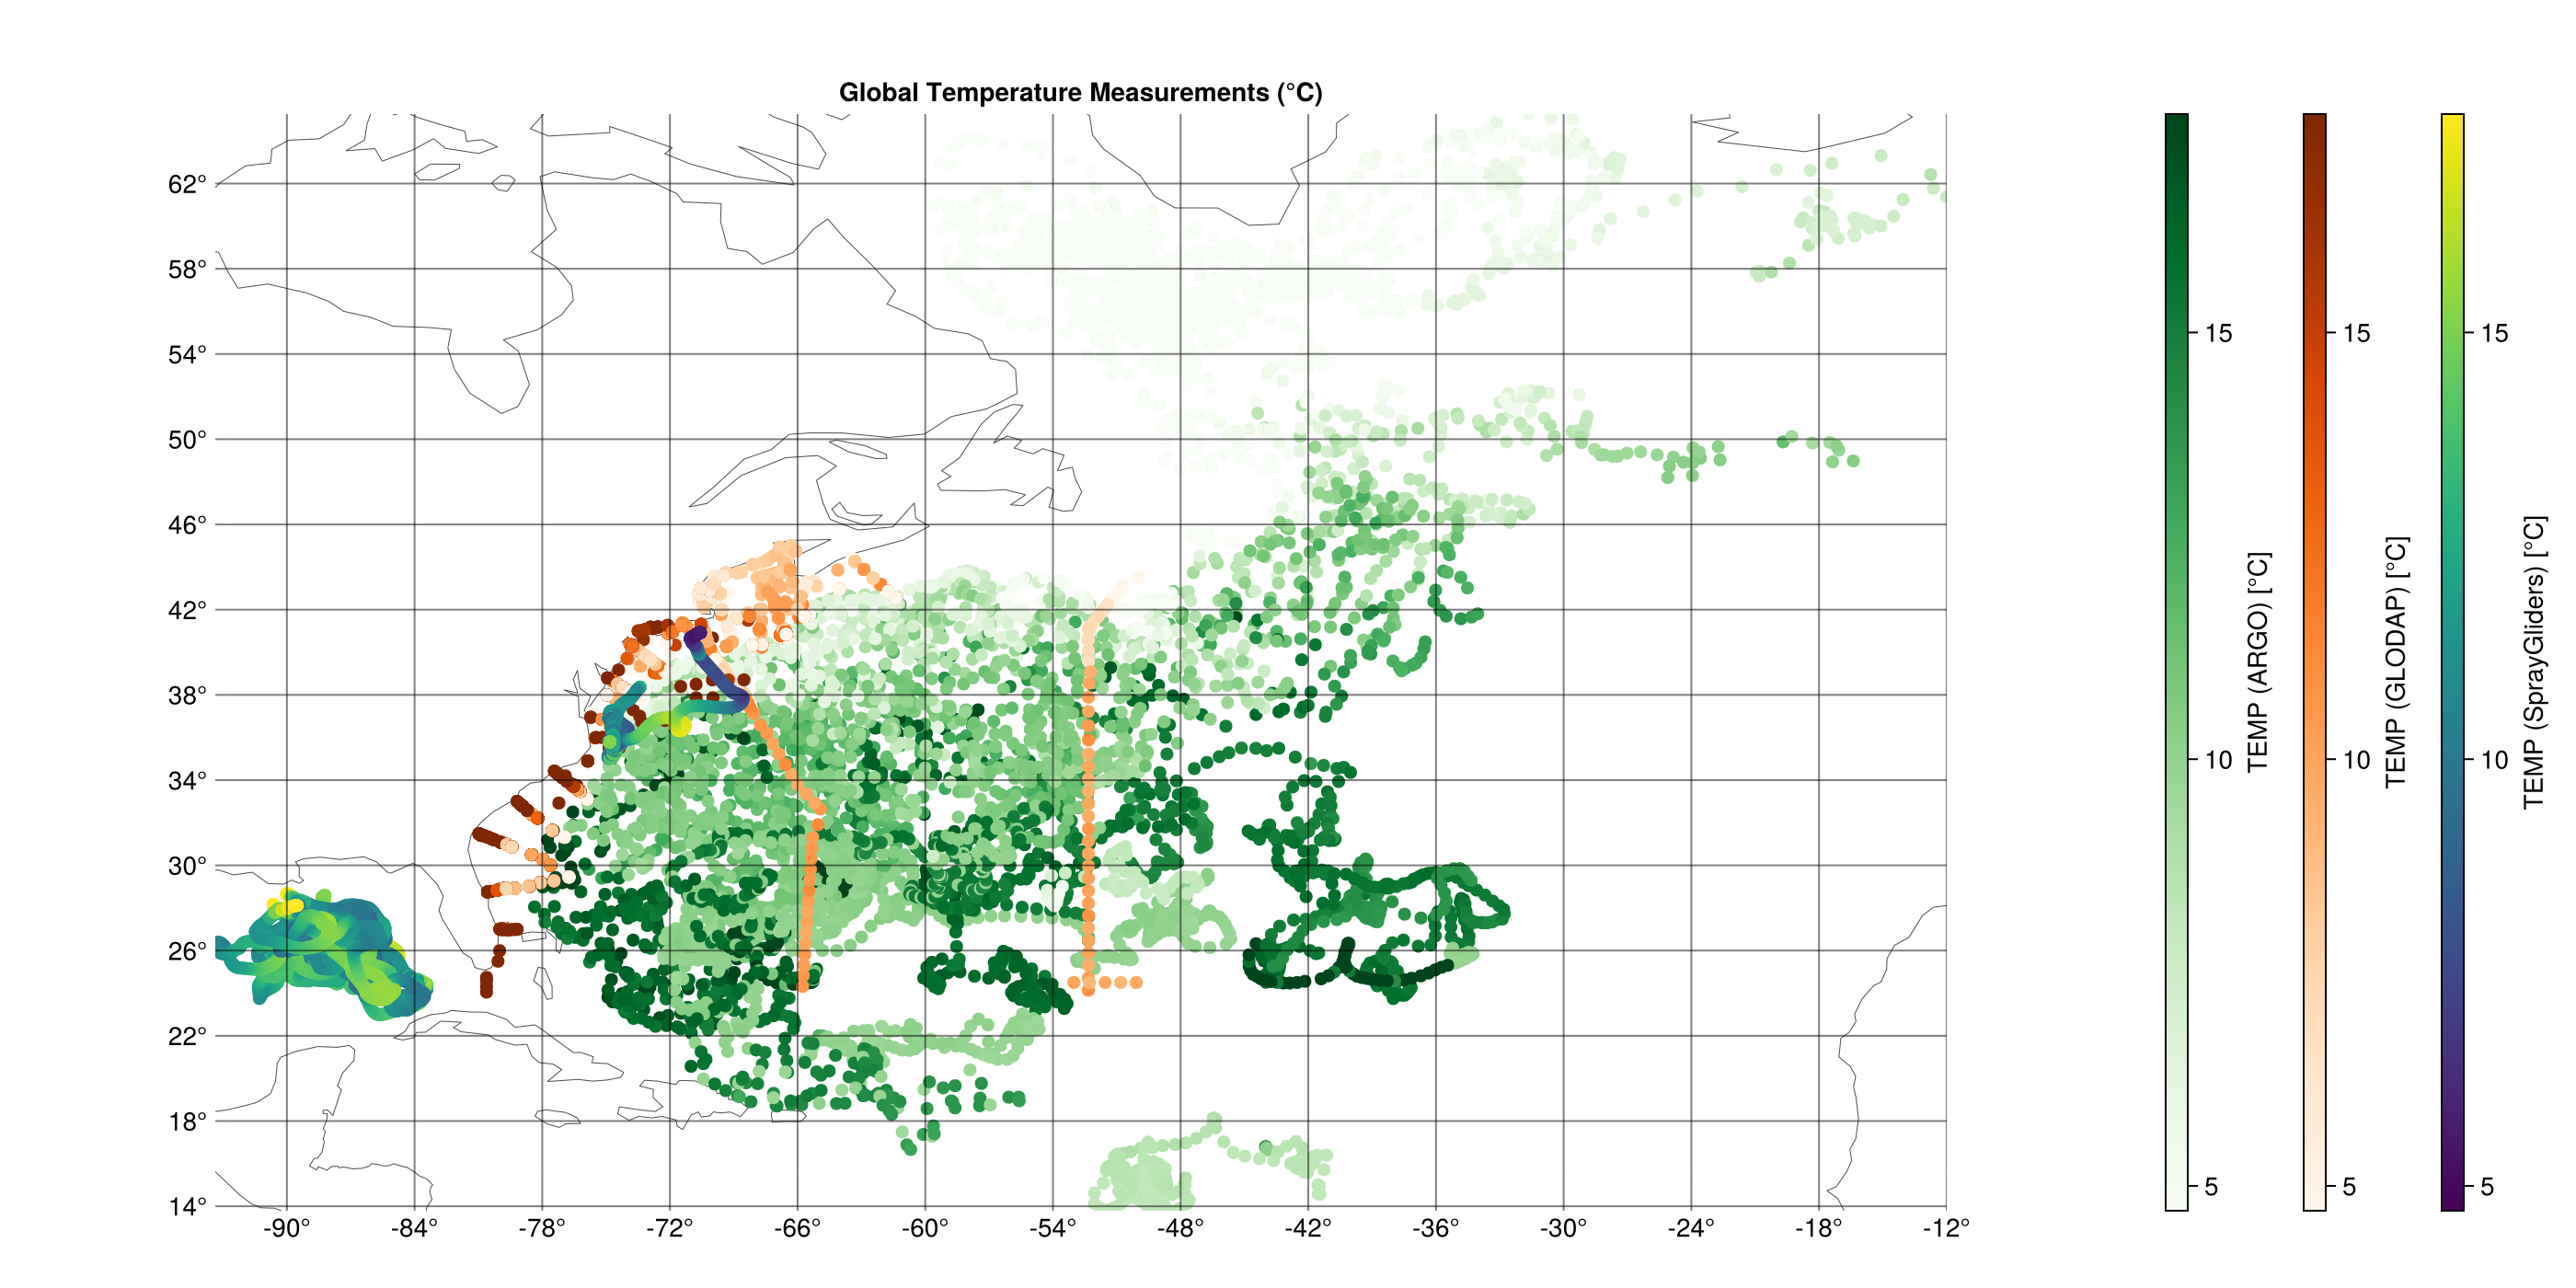

In [7]:
using Statistics

variables = (:JULD, :LATITUDE, :LONGITUDE, :TEMP, :DB_NAME)
df = get_subset_region(da.Dataset, variables=variables)
df = dropmissing(df, :TEMP)

println("Number of measurements: ", nrow(df1))

# Calculate colorbar limits (5th and 95th percentiles) from original data
grouped_map = combine(groupby(df, [:LATITUDE, :LONGITUDE, :DB_NAME]), 
    :TEMP => Statistics.mean => :temp_avg)

temps = grouped_map.temp_avg
cbar_min = Statistics.quantile(temps, 0.05)
cbar_max = Statistics.quantile(temps, 0.95)

println("Temperature range: ", round(cbar_min, digits=2), " to ", round(cbar_max, digits=2), " °C")

# Calculate lat/lon limits from data
lon_min, lon_max = extrema(df.LONGITUDE)
lat_min, lat_max = extrema(df.LATITUDE)

# Create figure with GeoAxis for coastlines
fig = Figure(size = (1400, 700))
ax = GeoAxis(fig[1, 1],
    xlabel = "Longitude",
    ylabel = "Latitude",
    title = "Global Temperature Measurements (°C)",
    dest = "+proj=eqc",  # Equidistant cylindrical projection
    limits = (lon_min, lon_max, lat_min, lat_max))

# Add coastlines
lines!(ax, GeoMakie.coastlines(), color = :gray30, linewidth = 0.5)

# Define colors for each source
source_colors = Dict(
    "ARGO" => :Greens,
    "GLODAP" => :Oranges,
    "SPRAY" => :Blues
)

# Get unique sources
sources = sort(unique(skipmissing(grouped_map.DB_NAME)))

# Plot each data source using original data points
for (i, source) in enumerate(sources)
    source_data = grouped_map[.!ismissing.(grouped_map.DB_NAME) .& (grouped_map.DB_NAME .== source), :]
    
    if DataFrames.nrow(source_data) > 0
        cmap = get(source_colors, source, :viridis)
        
        scatter!(ax, source_data.LONGITUDE, source_data.LATITUDE,
            color = source_data.temp_avg,
            colormap = cmap,
            colorrange = (cbar_min, cbar_max),
            markersize = 10)
        
        # Add colorbar
        Colorbar(fig[1, i+1], 
            limits = (cbar_min, cbar_max),
            colormap = cmap,
            label = "TEMP ($(source)) [°C]")
    end
end

fig

## Summary Statistics by Data Source

In [8]:
stats = combine(groupby(df, :DB_NAME),
    :TEMP => length => :n_bins,
    :TEMP => Statistics.mean => :mean_temp,
    :TEMP => Statistics.std => :std_temp,
    :TEMP => minimum => :min_temp,
    :TEMP => maximum => :max_temp
)

stats

Row,DB_NAME,n_bins,mean_temp,std_temp,min_temp,max_temp
,String?,Int64,Float32,Float32,Float32,Float32
1,ARGO,3455525,10.1297,6.61311,-1.643,30.908
2,GLODAP,7383,-74.4863,928.149,-9999.0,31.7353
3,SprayGliders,914099,11.6277,5.92316,3.93609,31.3847


## Suggested Exercises

Try modifying this notebook to:
- Filter by different time periods or regions
- Map a different parameter (e.g., salinity: `:PSAL`)
- Add pressure filtering to `variables` (e.g., include `:PRES` and filter for surface data)
- Create time series or depth profile plots
- Compare different regions

If you encounter any issues, please [reach out](mailto:enrico.milanese@whoi.edu)!